# EDA
#### Code for proportion plot of 10 random 1% samples from the Histopathologic Cancer Detection train labels. 

In [3]:
# Import necessary modules
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os
from PIL import Image
from os import listdir
from os.path import isfile, join
from itertools import chain

In [5]:
# Read training labels csv
eda = pd.read_csv('train_labels.csv') #, usecols = ['label']
eda['T_F'] = np.where(eda['label']== 0, 'False', 'True')
eda

,id,label,T_F
0,f38a6374c348f90b587e046aac6079959adf3835,0,False
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1,True
2,755db6279dae599ebb4d39a9123cce439965282d,0,False
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0,False
4,068aba587a4950175d04c680d38943fd488d6a9d,0,False
...,...,...,...
220020,53e9aa9d46e720bf3c6a7528d1fca3ba6e2e49f6,0,False
220021,d4b854fe38b07fe2831ad73892b3cec877689576,1,True
220022,3d046cead1a2a5cbe00b2b4847cfb7ba7cf5fe75,0,False
220023,f129691c13433f66e1e0671ff1fe80944816f5a2,0,False


In [6]:
# For EDA I get 10 random samples of the training set of 1% of the population
# For loop results in two lists with the counts of zeros and ones of each sample.
rs = np.round(np.linspace(1,21,10))

count_true = []
count_false = []

for number in rs:

    sample_eda = eda.sample(frac=0.01, replace=False, random_state=int(number))
    sample_eda.sort_values(by=['label'], inplace= True)

    group_sample = sample_eda.groupby('label')['label'].count()
    
    count_false.append(group_sample.loc[0])
    count_true.append(group_sample.loc[1])

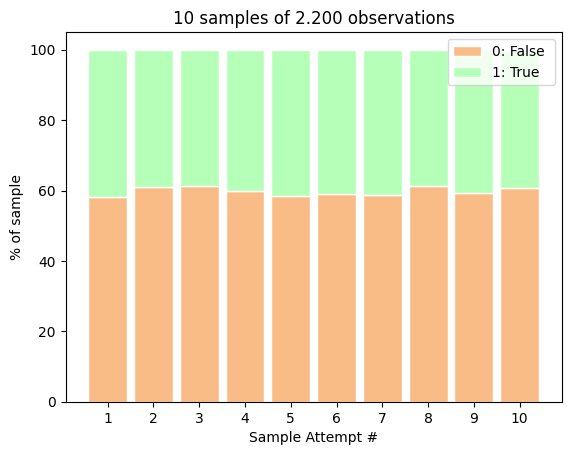

In [72]:
# Of the 10 samples I make a plot displaying the proportion of zeros and ones 
# for each sample. 
r = np.arange(1,11,1)
raw_data = {'0': count_false, '1': count_true}
total_sample = pd.DataFrame(raw_data)
total_sample

totals = [i+j for i,j in zip(total_sample['0'], total_sample['1'])]
Zero = [i / j * 100 for i,j in zip(total_sample['0'], totals)]
One = [i / j * 100 for i,j in zip(total_sample['1'], totals)]

# plot
barWidth = 0.85
names = ('1','2','3','4','5','6','7','8','9','10')
# Green Bars
plt.bar(r, Zero, color='#f9bc86', edgecolor='white', width=barWidth)
# Orange Bars
plt.bar(r, One, bottom=Zero, color='#b5ffb9', edgecolor='white', width=barWidth)


plt.xticks(r, names)
plt.xlabel("Sample Attempt #")
plt.ylabel('% of sample')
plt.legend(['0: False ', '1: True'], loc = "upper right")
plt.title("10 samples of 2.200 observations")

plt.show()
